<a href="https://colab.research.google.com/github/haridevsreebhavan/AI-Training-/blob/main/Assignments/Assignment%208/Assignment_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 8: Hybrid Agentic Workflows using LangGraph
## Telecom Domain – Intelligent Network Incident Resolution System




In [1]:
!pip install -q -U langgraph langchain langchain-openai python-dotenv pydantic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.3/234.3 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.3/114.3 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.13.4 which is incompatible.


In [2]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
import json

In [3]:
class TelecomState(TypedDict, total=False):
    complaint: str
    issue_type: str
    severity: str
    impact_scope: str
    sentiment: str

    tower_status: str
    crm_history: Dict[str, Any]
    billing_status: str
    device_status: str
    outage_status: str

    assigned_team: str
    escalation_required: bool

    findings_summary: str
    customer_response: str
    technician_notes: str
    estimated_resolution_time: str

In [5]:
def complaint_understanding_agent(state: TelecomState) -> TelecomState:
    complaint = state["complaint"].lower()

    # Detect issue type
    if "bill" in complaint or "charged" in complaint:
        issue_type = "billing"
    elif "sim" in complaint:
        issue_type = "sim_device"
    elif "slow" in complaint or "internet" in complaint:
        issue_type = "slow_internet"
    elif "no signal" in complaint or "outage" in complaint:
        issue_type = "network_outage"
    else:
        issue_type = "general_network"

    # Detect severity
    if "entire area" in complaint or "extremely" in complaint:
        severity = "critical"
    elif "urgent" in complaint or "since morning" in complaint:
        severity = "high"
    else:
        severity = "medium"


    if "entire area" in complaint or "all users" in complaint:
        impact_scope = "region"
    elif "we" in complaint or "multiple" in complaint:
        impact_scope = "multiple_users"
    else:
        impact_scope = "individual"


    if "extremely" in complaint or "stopped" in complaint:
        sentiment = "frustrated"
    else:
        sentiment = "neutral"

    return {
        "issue_type": issue_type,
        "severity": severity,
        "impact_scope": impact_scope,
        "sentiment": sentiment
    }

In [6]:
def tower_health_check(state: TelecomState) -> TelecomState:
    if state["issue_type"] in ["network_outage", "slow_internet"]:
        status = random.choice(["Healthy", "Congested", "Down"])
    else:
        status = "Not Applicable"
    return {"tower_status": status}


def crm_history_check(state: TelecomState) -> TelecomState:
    return {
        "crm_history": {
            "previous_complaints": random.randint(0, 5),
            "vip_customer": random.choice([True, False])
        }
    }


def billing_check(state: TelecomState) -> TelecomState:
    if state["issue_type"] == "billing":
        status = "Dispute Found"
    else:
        status = "No Issues"
    return {"billing_status": status}


def device_compatibility_check(state: TelecomState) -> TelecomState:
    if state["issue_type"] == "sim_device":
        status = "SIM Provisioning Error"
    else:
        status = "Compatible"
    return {"device_status": status}


def outage_monitoring_check(state: TelecomState) -> TelecomState:
    if state["impact_scope"] == "region":
        status = "Major Regional Outage"
    else:
        status = "No Known Outage"
    return {"outage_status": status}

In [7]:
def intelligent_router(state: TelecomState) -> TelecomState:
    if state["billing_status"] == "Dispute Found":
        team = "Billing Agent"
    elif state["tower_status"] == "Down" or state["outage_status"] == "Major Regional Outage":
        team = "Network Operations Agent"
    elif state["device_status"] == "SIM Provisioning Error":
        team = "Device Support Agent"
    else:
        team = "General Support Agent"

    escalation_required = (
        state["severity"] == "critical"
        or state["crm_history"]["previous_complaints"] >= 3
    )

    if escalation_required:
        team = "Escalation Agent"

    return {
        "assigned_team": team,
        "escalation_required": escalation_required
    }

In [8]:
def generate_findings_summary(state: TelecomState) -> TelecomState:
    summary = (
        f"Issue Type: {state['issue_type']}, "
        f"Severity: {state['severity']}, "
        f"Assigned Team: {state['assigned_team']}"
    )
    return {"findings_summary": summary}


def generate_customer_response(state: TelecomState) -> TelecomState:
    response = (
        f"Dear Customer, your complaint has been assigned to "
        f"{state['assigned_team']}. "
        f"Estimated resolution time: {state.get('estimated_resolution_time', 'TBD')}."
    )
    return {"customer_response": response}


def generate_technician_notes(state: TelecomState) -> TelecomState:
    notes = (
        f"Investigate {state['issue_type']}. "
        f"Tower={state['tower_status']}, "
        f"Billing={state['billing_status']}, "
        f"Device={state['device_status']}."
    )
    return {"technician_notes": notes}


def estimate_resolution_time(state: TelecomState) -> TelecomState:
    if state["assigned_team"] == "Escalation Agent":
        eta = "1-2 hours"
    elif state["assigned_team"] == "Network Operations Agent":
        eta = "2-4 hours"
    elif state["assigned_team"] == "Billing Agent":
        eta = "30-60 minutes"
    elif state["assigned_team"] == "Device Support Agent":
        eta = "15-30 minutes"
    else:
        eta = "1-2 hours"
    return {"estimated_resolution_time": eta}

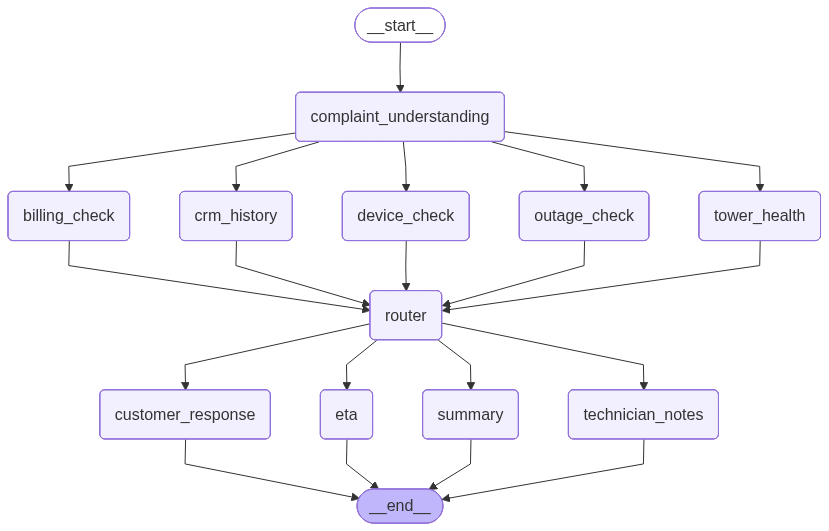

In [9]:
workflow = StateGraph(TelecomState)


workflow.add_node("complaint_understanding", complaint_understanding_agent)

workflow.add_node("tower_health", tower_health_check)
workflow.add_node("crm_history", crm_history_check)
workflow.add_node("billing_check", billing_check)
workflow.add_node("device_check", device_compatibility_check)
workflow.add_node("outage_check", outage_monitoring_check)

workflow.add_node("router", intelligent_router)

workflow.add_node("summary", generate_findings_summary)
workflow.add_node("eta", estimate_resolution_time)
workflow.add_node("customer_response", generate_customer_response)
workflow.add_node("technician_notes", generate_technician_notes)


workflow.add_edge(START, "complaint_understanding")

for node in [
    "tower_health",
    "crm_history",
    "billing_check",
    "device_check",
    "outage_check",
]:
    workflow.add_edge("complaint_understanding", node)
    workflow.add_edge(node, "router")


workflow.add_edge("router", "summary")
workflow.add_edge("router", "eta")
workflow.add_edge("router", "customer_response")
workflow.add_edge("router", "technician_notes")

for node in [
    "summary",
    "eta",
    "customer_response",
    "technician_notes",
]:
    workflow.add_edge(node, END)

# Compile graph
app = workflow.compile()
app